# Competencia Aprendizaje de Máquina 2026-10
## Parte 1 – Clasificación de textos por década

**Tarea:** Predecir la década (tres primeros dígitos del año) en que fue escrito un párrafo en español histórico. Las décadas van de 150 (años 1500–1509) a 188 (años 1880–1889), 39 clases.

**Estrategia:** Combinar múltiples representaciones de texto (char n-grams + word n-grams) con un clasificador LinearSVC optimizado, además de features de ingeniería manual.

## 1. Importación de Librerías y Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import re
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from scipy.sparse import hstack

import warnings
warnings.filterwarnings('ignore')

In [2]:
train_df = pd.read_csv('./train.csv', engine='python', on_bad_lines='skip')
test_df = pd.read_csv('./eval.csv')

print(f"Registros de entrenamiento: {train_df.shape[0]}")
print(f"Registros de prueba: {test_df.shape[0]}")

Registros de entrenamiento: 31403
Registros de prueba: 3490


In [3]:
print('Distribución de décadas:')
print(train_df['decade'].value_counts().sort_index())
print()
print('Número de clases:', train_df['decade'].nunique())
print('Rango:', train_df['decade'].min(), '→', train_df['decade'].max())
print()
print('Longitud de texto (caracteres):')
print(train_df['text'].str.len().describe())

Distribución de décadas:
decade
150    786
151    812
152    785
153    775
154    830
155    836
156    792
157    827
158    778
159    802
160    848
161    787
162    808
163    827
164    804
165    814
166    779
167    831
168    822
169    771
170    833
171    816
172    842
173    802
174    807
175    817
176    754
177    782
178    831
179    809
180    825
181    795
182    808
183    794
184    802
185    803
186    773
187    787
188    809
Name: count, dtype: int64

Número de clases: 39
Rango: 150 → 188

Longitud de texto (caracteres):
count    31403.000000
mean       520.568290
std        530.947792
min        120.000000
25%        182.000000
50%        315.000000
75%        643.000000
max       7418.000000
Name: text, dtype: float64


## 2. Preprocesamiento

Limpieza mínima para preservar señales ortográficas de época (puntuación antigua, uso de mayúsculas, etc.).

In [4]:
def clean_text(text):
    """Limpieza mínima: minúsculas y normalización de espacios.
    Se mantiene puntuación y caracteres especiales como indicadores de época."""
    text = text.lower()
    text = text.replace('\n', ' ').replace('\r', ' ')
    # Normalizar espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['text_clean'] = train_df['text'].apply(clean_text)
test_df['text_clean'] = test_df['text'].apply(clean_text)

X = train_df['text_clean']
y = train_df['decade']

print(f"Ejemplo de texto limpio (primeros 200 chars):")
print(X.iloc[0][:200])

Ejemplo de texto limpio (primeros 200 chars):
honorarias ¡jubiladas. 57 dit.ad pontem de poreft.proreg.118,3, $.9.m.-70 pag.4.1. 3 ste ph.gratian. difcept.291, áqu len nes parece que aísilte, o ayuda calsiodoro lib,6.epuft.s 2.donde * llama oclos


In [9]:
import re

def clean_text2(text_series):
    """Limpieza mínima manteniendo señal histórica"""

    text_series = text_series.str.lower()

    text_series = (
        text_series
        .str.replace('\n', ' ', regex=False)
        .str.replace('\r', ' ', regex=False)
    )

    text_series = text_series.str.replace(r'\s+', ' ', regex=True).str.strip()

    return text_series



## 3. Exploración Rápida de Modelos Base

Probamos distintas configuraciones individuales con validación cruzada para entender qué funciona mejor antes de combinar.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
import time

print("Vectorizando...")
start = time.time()
tfidf = TfidfVectorizer(analyzer='char', ngram_range=(2,5),
                         max_features=50000, sublinear_tf=True,
                         min_df=2, max_df=0.85)
X_tfidf = tfidf.fit_transform(X)
print(f"Listo en {time.time()-start:.1f}s")
print(f"Shape: {X_tfidf.shape}")

Vectorizando...
Listo en 81.5s
Shape: (31403, 50000)


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
from sklearn.linear_model import SGDClassifier



pipe_char = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char', ngram_range=(2,5),
                              max_features=50000, sublinear_tf=True,
                              min_df=2, max_df=0.85)),
    ('clf', SGDClassifier(loss='hinge', alpha=1e-4, max_iter=1000, random_state=42))
])
scores_char = cross_val_score(pipe_char, X, y, cv=cv, scoring='accuracy')
print(f"Char (2,5) + SGD: {scores_char.mean():.4f} (+/- {scores_char.std()*2:.4f})")

Char (2,5) + SGD: 0.2540 (+/- 0.0019)


In [8]:

# --- Experimento 2: Char n-grams (2,6) + LinearSVC ---
pipe_char6 = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char', ngram_range=(2,6),
                              max_features=80000, sublinear_tf=True,
                              min_df=2, max_df=0.85)),
    ('clf', LinearSVC(C=1.0, max_iter=5000))
])
scores_char6 = cross_val_score(pipe_char6, X, y, cv=cv, scoring='accuracy')
print(f"Char (2,6) + LinearSVC: {scores_char6.mean():.4f} (+/- {scores_char6.std()*2:.4f})")


Char (2,6) + LinearSVC: 0.2668 (+/- 0.0060)


In [9]:

# --- Experimento 3: Word n-grams (1,2) + LinearSVC ---
pipe_word = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1,2),
                              max_features=50000, sublinear_tf=True,
                              min_df=2, max_df=0.85)),
    ('clf', LinearSVC(C=1.0, max_iter=5000))
])
scores_word = cross_val_score(pipe_word, X, y, cv=cv, scoring='accuracy')
print(f"Word (1,2) + LinearSVC: {scores_word.mean():.4f} (+/- {scores_word.std()*2:.4f})")


Word (1,2) + LinearSVC: 0.2036 (+/- 0.0123)


In [10]:

# --- Experimento 4: Char_wb n-grams (2,5) + LinearSVC ---
pipe_charwb = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2,5),
                              max_features=50000, sublinear_tf=True,
                              min_df=2, max_df=0.85)),
    ('clf', LinearSVC(C=0.5, max_iter=5000))
])
scores_charwb = cross_val_score(pipe_charwb, X, y, cv=cv, scoring='accuracy')
print(f"Char_wb (2,5) + LinearSVC: {scores_charwb.mean():.4f} (+/- {scores_charwb.std()*2:.4f})")

Char_wb (2,5) + LinearSVC: 0.2670 (+/- 0.0052)


## 4. Modelo Combinado: FeatureUnion (Char + Word + Char_wb)

Combinamos múltiples vectorizadores para capturar señales complementarias:
- **Char n-grams**: Capturan patrones ortográficos que cambian con el tiempo (grafías antiguas como 'ph' vs 'f', 'ss' vs 's', uso de 'ñ', etc.)
- **Word n-grams**: Capturan vocabulario y expresiones propias de cada época.
- **Char_wb n-grams**: Capturan morfología de palabras respetando fronteras.

In [ ]:
# Definición del modelo combinado
combined_pipeline = Pipeline([
    ('features', FeatureUnion([
        ('char', TfidfVectorizer(
            analyzer='char',
            ngram_range=(2, 6),
            max_features=150000,
            sublinear_tf=True,
            min_df=2,
            max_df=0.85
        )),
        ('word', TfidfVectorizer(
            analyzer='word',
            ngram_range=(1, 2),
            max_features=80000,
            sublinear_tf=True,
            min_df=2,
            max_df=0.85
        )),
        ('char_wb', TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=(3, 5),
            max_features=80000,
            sublinear_tf=True,
            min_df=2,
            max_df=0.85
        )),
    ])),
    ('clf', LinearSVC(C=1.0, max_iter=5000, class_weight=None))
])

# Evaluación con validación cruzada
scores_combined = cross_val_score(combined_pipeline, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f"Modelo Combinado (char+word+char_wb) + LinearSVC:")
print(f"  Accuracy: {scores_combined.mean():.4f} (+/- {scores_combined.std()*2:.4f})")

Modelo Combinado (char+word+char_wb) + LinearSVC:
  Accuracy: 0.2675 (+/- 0.0043)


## 5. Optimización de Hiperparámetros

GridSearch enfocado en los parámetros más impactantes: C del clasificador y max_features de los vectorizadores.

In [12]:
# Espacio de búsqueda enfocado en los parámetros más impactantes
param_grid = {
    'clf__C': [0.3, 0.5, 0.8, 1.0, 1.5, 2.0],
}

grid_search = GridSearchCV(
    combined_pipeline,
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(X, y)

print(f"\nMejor Accuracy en CV: {grid_search.best_score_:.4f}")
print(f"Mejores parámetros: {grid_search.best_params_}")

# Mostrar todos los resultados
results = pd.DataFrame(grid_search.cv_results_)
results = results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results = results.sort_values('rank_test_score')
print("\nResultados completos:")
print(results.to_string(index=False))

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Mejor Accuracy en CV: 0.2740
Mejores parámetros: {'clf__C': 0.3}

Resultados completos:
         params  mean_test_score  std_test_score  rank_test_score
{'clf__C': 0.3}         0.273987        0.003070                1
{'clf__C': 0.5}         0.270930        0.001485                2
{'clf__C': 0.8}         0.268414        0.001916                3
{'clf__C': 1.0}         0.267490        0.002164                4
{'clf__C': 1.5}         0.266121        0.002610                5
{'clf__C': 2.0}         0.265357        0.002559                6


## 6. Búsqueda Adicional

Si el mejor C está en un extremo del rango, ampliamos la búsqueda. También exploramos variantes del char n-gram range.

In [13]:
# Búsqueda más amplia sobre la configuración de los vectorizadores
param_grid_2 = {
    'features__char__ngram_range': [(2,5), (2,6), (3,6)],
    'features__char__max_features': [100000, 150000, 200000],
    'clf__C': [grid_search.best_params_['clf__C']],  # Fijamos el mejor C encontrado
}

grid_search_2 = GridSearchCV(
    combined_pipeline,
    param_grid_2,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search_2.fit(X, y)

print(f"\nMejor Accuracy en CV: {grid_search_2.best_score_:.4f}")
print(f"Mejores parámetros: {grid_search_2.best_params_}")

results2 = pd.DataFrame(grid_search_2.cv_results_)
results2 = results2[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results2 = results2.sort_values('rank_test_score')
print("\nResultados completos:")
print(results2.to_string(index=False))

Fitting 5 folds for each of 9 candidates, totalling 45 fits

Mejor Accuracy en CV: 0.2761
Mejores parámetros: {'clf__C': 0.3, 'features__char__max_features': 200000, 'features__char__ngram_range': (2, 5)}

Resultados completos:
                                                                                        params  mean_test_score  std_test_score  rank_test_score
{'clf__C': 0.3, 'features__char__max_features': 200000, 'features__char__ngram_range': (2, 5)}         0.276088        0.002677                1
{'clf__C': 0.3, 'features__char__max_features': 150000, 'features__char__ngram_range': (2, 5)}         0.275356        0.003188                2
{'clf__C': 0.3, 'features__char__max_features': 100000, 'features__char__ngram_range': (2, 5)}         0.275324        0.002966                3
{'clf__C': 0.3, 'features__char__max_features': 200000, 'features__char__ngram_range': (2, 6)}         0.274210        0.002873                4
{'clf__C': 0.3, 'features__char__max_features':

Usamos el mejor modelo del GridSearch, verificamos con CV

In [ ]:
best_model = grid_search_2.best_estimator_
best_score = grid_search_2.best_score_
best_params = grid_search_2.best_params_

# Verificación final con CV (del estimator ya reentrenado)
scores_final = cross_val_score(best_model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f"Accuracy Final CV: {scores_final.mean():.4f} (+/- {scores_final.std()*2:.4f})")

Accuracy Final CV: 0.2761 (+/- 0.0054)


## 7. Búsqueda Adicional 2

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    train_df['text'],
    train_df['decade'],
    test_size=0.2,
    random_state=42,
    stratify = y #Importante para clasificación multiclase, asegura que cada clase esté representada proporcionalmente en train y test
)

# Definición del modelo combinado
combined_pipeline2 = Pipeline([
    ("cleaner", FunctionTransformer(clean_text2)),  
    ('features', FeatureUnion([
        ('char', TfidfVectorizer( 
            analyzer='char',
            ngram_range=(2, 5),
            max_features=200000,
            sublinear_tf=True,
            min_df=2,
            max_df=0.85
        )),
        ('word', TfidfVectorizer(
            analyzer='word',
            ngram_range=(1, 2),
            max_features=80000,
            sublinear_tf=True,
            min_df=2,
            max_df=0.85
        )),
        ('char_wb', TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=(3, 5),
            max_features=80000,
            sublinear_tf=True,
            min_df=2,
            max_df=0.85
        )),
    ])),
    ('clf', LinearSVC(C=0.3, max_iter=5000, class_weight=None))
])

# Evaluación con validación cruzada
scores_combined = cross_val_score(combined_pipeline2, train_df['text'], train_df['decade'], cv=cv, scoring='accuracy', n_jobs=-1)
print(f"Modelo Combinado (char+word+char_wb) + LinearSVC:")
print(f"  Accuracy: {scores_combined.mean():.4f} (+/- {scores_combined.std()*2:.4f})")

Modelo Combinado (char+word+char_wb) + LinearSVC:
  Accuracy: 0.2761 (+/- 0.0054)


In [11]:
# Búsqueda más amplia sobre la configuración de los vectorizadores
param_grid_3 = {
    
}

grid_search_3 = GridSearchCV(
    combined_pipeline2,
    param_grid_3,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    refit=True
)

In [12]:
grid_search_3.fit(X_train, y_train)
print(f"\nMejor Accuracy en CV: {grid_search_3.best_score_:.4f}")
print(f"Mejores parámetros: {grid_search_3.best_params_}")

results3 = pd.DataFrame(grid_search_3.cv_results_)
results3 = results3[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results3 = results3.sort_values('rank_test_score')
print("\nResultados completos:")
print(results3.to_string(index=False))



Fitting 5 folds for each of 1 candidates, totalling 5 fits

Mejor Accuracy en CV: 0.2634
Mejores parámetros: {}

Resultados completos:
params  mean_test_score  std_test_score  rank_test_score
    {}         0.263355        0.002555                1


Ahora, vamos a entender los resultados del modelo para mejorarlo

In [13]:
# Generar predicciones sobre el conjunto de evaluación
model = grid_search_3.best_estimator_
y_pred = model.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         150       0.72      0.80      0.76       157
         151       0.58      0.80      0.67       162
         152       0.57      0.66      0.61       157
         153       0.58      0.73      0.65       155
         154       0.55      0.63      0.59       166
         155       0.42      0.35      0.38       167
         156       0.33      0.40      0.36       158
         157       0.30      0.31      0.30       166
         158       0.24      0.30      0.27       156
         159       0.24      0.27      0.25       160
         160       0.17      0.14      0.15       170
         161       0.15      0.13      0.14       157
         162       0.20      0.19      0.19       162
         163       0.14      0.13      0.13       166
         164       0.19      0.17      0.18       161
         165       0.07      0.06      0.07       163
         166       0.10      0.06      0.08       156
         167       0.20    

In [14]:
import pandas as pd
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(cm)

print(cm_df)

     0    1    2    3    4   5   6   7   8   9   ...  29  30  31  32  33  34  \
0   125    8    6    6    2   0   0   0   0   0  ...   0   4   0   0   0   1   
1     0  129    2    6    7   0   0   2   2   1  ...   1   0   0   2   1   0   
2     2   15  103    9    6   2   0   2   1   1  ...   0   1   2   1   1   0   
3     0   12    0  113   19   0   1   4   0   0  ...   1   1   0   0   1   0   
4     2   11    1   17  105   7   3   1   5   1  ...   0   1   0   2   0   0   
5     1   12    2   11   13  58  10  11  13   5  ...   0   0   0   1   0   2   
6     2    3    3    8   10   8  63  12  12   7  ...   0   0   0   1   1   0   
7     0    4    1    5    1  12   6  52  16  15  ...   0   0   1   0   0   0   
8     1    0    1    2    3   4   9  19  47  26  ...   0   0   0   1   0   0   
9     0    1    1    1    2   6  10   9  17  43  ...   0   1   0   0   0   0   
10    1    2    1    2    0   5  19   8  12  14  ...   0   1   0   2   0   0   
11    1    0    0    1    0   3   7  12 

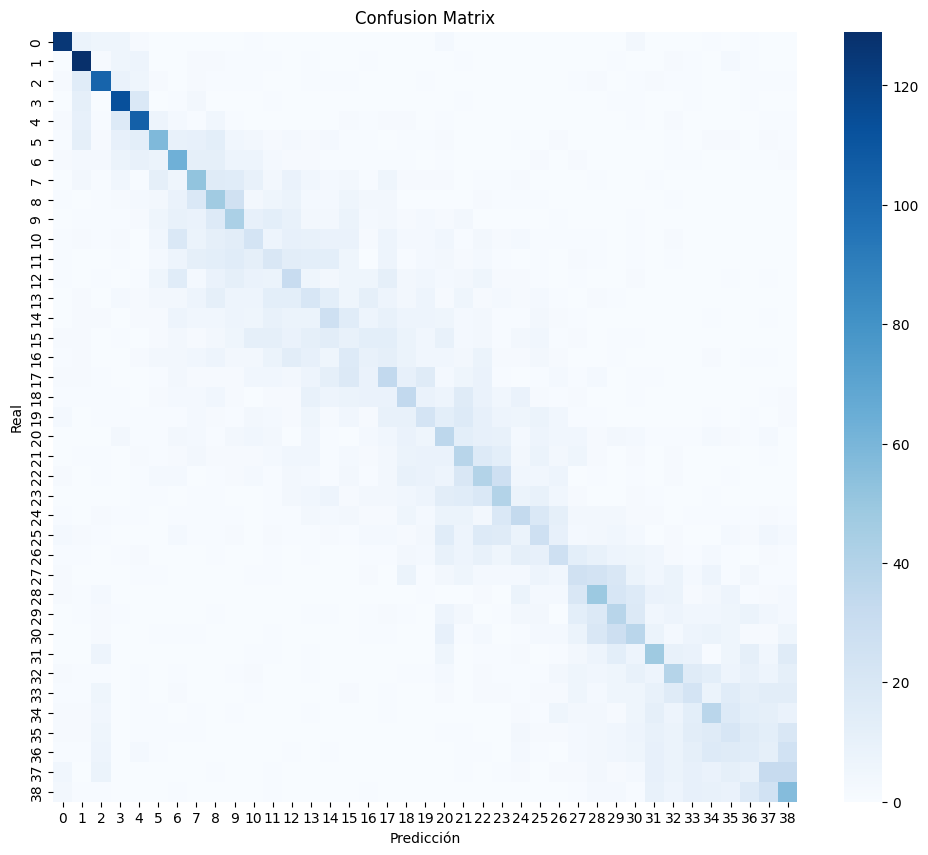

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(cm_df, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

In [17]:
import numpy as np
# extraer FeatureUnion entrenado
feature_union = model.named_steps["features"]

char_vect = feature_union.transformer_list[0][1]
word_vect = feature_union.transformer_list[1][1]
charwb_vect = feature_union.transformer_list[2][1]

# nombres de features
char_features = char_vect.get_feature_names_out()
word_features = word_vect.get_feature_names_out()
charwb_features = charwb_vect.get_feature_names_out()

# coeficientes del modelo entrenado
coef = model.named_steps["clf"].coef_

# importancia promedio entre clases
importance = np.mean(np.abs(coef), axis=0)

# tamaños de bloques
n_char = len(char_features)
n_word = len(word_features)
n_charwb = len(charwb_features)

# separar bloques
importance_char = importance[:n_char]

importance_word = importance[n_char:n_char+n_word]

importance_charwb = importance[n_char+n_word:]

# top 30
top_char = np.argsort(importance_char)[::-1][:30]
top_word = np.argsort(importance_word)[::-1][:30]
top_charwb = np.argsort(importance_charwb)[::-1][:30]

print("\n===== TOP 30 CHAR FEATURES =====\n")
for i in top_char:
    print(f"{char_features[i]:<15} {importance_char[i]:.6f}")

print("\n===== TOP 30 WORD FEATURES =====\n")
for i in top_word:
    print(f"{word_features[i]:<20} {importance_word[i]:.6f}")

print("\n===== TOP 30 CHAR_WB FEATURES =====\n")
for i in top_charwb:
    print(f"{charwb_features[i]:<15} {importance_charwb[i]:.6f}")


===== TOP 30 CHAR FEATURES =====

 ,              0.282603
 ,              0.280109
st              0.165672
 s              0.161791
 á              0.159285
 á              0.156457
s ,             0.150138
s ,             0.148010
, y             0.145091
 , y            0.144708
-               0.144239
, y             0.142672
 , y            0.141044
a ,             0.139939
a ,             0.137913
.               0.132739
se              0.130707
á               0.129578
 a              0.126392
^               0.126182
—               0.125089
oe              0.123754
ef              0.123710
, qu            0.123540
o ,             0.123096
, q             0.122884
o ,             0.122119
ft              0.118994
¬               0.116615
a y             0.116610

===== TOP 30 WORD FEATURES =====

se                   0.165135
fe                   0.164401
de                   0.161453
un                   0.156470
más                  0.146679
oe                   0.139255


## 7. Modelo Final: Entrenamiento y Predicción

In [18]:
best_model = grid_search_3.best_estimator_

In [19]:
# Reentrenar con TODOS los datos de entrenamiento para la predicción final
best_model.fit(train_df['text'], train_df['decade'])

# Generar predicciones
predictions = best_model.predict(test_df['text'])

# Formatear el archivo de salida 
submission = pd.DataFrame({
    'id': test_df['id'],
    'answer': predictions
})

# Verificación rápida
print(f"Shape del submission: {submission.shape}")
print(f"Décadas predichas (distribución):")
print(submission['answer'].value_counts().sort_index())

# Guardar resultado
submission.to_csv('submission_final.csv', index=False)
print("\nArchivo 'submission_final.csv' generado correctamente.")

Shape del submission: (3490, 2)
Décadas predichas (distribución):
answer
150     88
151    121
152     95
153    117
154    116
155     82
156     95
157     80
158     95
159    102
160     88
161     84
162     71
163     87
164     72
165     92
166     52
167     91
168     96
169     84
170    101
171    106
172     88
173     98
174     87
175     87
176     63
177     60
178    105
179     83
180     89
181     90
182     86
183     75
184    100
185     96
186     73
187     83
188    112
Name: count, dtype: int64

Archivo 'submission_final.csv' generado correctamente.


## 8. Guardar Modelo

Se guarda el modelo entrenado con joblib, como indica el enunciado.

In [20]:
# Guardar modelo entrenado
joblib.dump(best_model, 'modelo_final_parte1.joblib')
print("Modelo guardado en 'modelo_final_parte1.joblib'")

# Verificar que se puede cargar correctamente
modelo_cargado = joblib.load('modelo_final_parte1.joblib')
pred_check = modelo_cargado.predict(test_df['text_clean'].head(5))
print(f"Verificación de carga - Predicciones de prueba: {pred_check}")

Modelo guardado en 'modelo_final_parte1.joblib'
Verificación de carga - Predicciones de prueba: [173 187 150 169 153]
